APPLYING SIM TO HARDWARE
HARDWARE CHECK:

In [19]:
#STEP 1

import time
import numpy as np

import importlib
import hardware_ops
import alignment_ops as A
import Simulation as S

In [95]:
hardware_ops = importlib.reload(hardware_ops)
A = importlib.reload(A)
S = importlib.reload(S)

In [113]:
try:
    H.shutdown()
except Exception as e:
    print("Shutdown warning:", e)

H = HardwareOps("hardware_config.json")

Shutting down piezos...
Shutting down quadcells...
Shutdown aligner with serial 69253622
Shutdown aligner with serial 69253977
Shutting down KDC101 linear stages...
Shutdown KDC101 linear stage with serial 27266900
Shutdown KDC101 linear stage with serial 27266901
Shutdown KDC101 linear stage with serial 27601694
Shutting down rotation stages...
Shutdown Newport rotation controller newport
All hardware safely shut down.


In [53]:
H.shutdown()

Shutting down piezos...
Shutting down quadcells...
Shutdown aligner with serial 69253622
Shutdown aligner with serial 69253977
Shutting down KDC101 linear stages...
Shutdown KDC101 linear stage with serial 27266900
Shutdown KDC101 linear stage with serial 27266901
Shutdown KDC101 linear stage with serial 27601694
Shutting down rotation stages...
Shutdown Newport rotation controller newport
All hardware safely shut down.


In [116]:
try:
    H.shutdown()
except Exception as e:
    print("Shutdown warning:", e)

import importlib
import hardware_ops
hardware_ops = importlib.reload(hardware_ops)

HardwareOps = hardware_ops.HardwareOps
H = HardwareOps("hardware_config.json")

Shutting down piezos...
Shutting down quadcells...
Shutdown aligner with serial 69253622
Shutdown aligner with serial 69253977
Shutting down KDC101 linear stages...
Shutdown KDC101 linear stage with serial 27266900
Shutdown KDC101 linear stage with serial 27266901
Shutdown KDC101 linear stage with serial 27601694
Shutting down rotation stages...
Shutdown Newport rotation controller newport
All hardware safely shut down.


In [20]:
#STEP 2

HardwareOps = hardware_ops.HardwareOps
H = HardwareOps("hardware_config.json")

DeviceNotReadyException: Device is not connected
   at Thorlabs.MotionControl.DeviceManagerCLI.ThorlabsGenericCoreDeviceCLI.VerifyDeviceConnected(Int32 functionDepth)
   at Thorlabs.MotionControl.KCube.PositionAlignerCLI.KCubePositionAligner.Connect(String serialNo)

In [22]:
def read_qc(): #the important one
    vals = np.array(H.quads.get_xy_position(), dtype=float)
    print(f"QC: x1={vals[0]:+.4f}, y1={vals[1]:+.4f}, x2={vals[2]:+.4f}, y2={vals[3]:+.4f}")
    return vals

def qc_y(vals):
    return np.array([vals[1], vals[3]], dtype=float)

def check_qc_safe(vals, limit=3.5):
    y = qc_y(vals)
    if np.max(np.abs(y)) > limit:
        raise RuntimeError(f"QC y too close to edge: {y}, limit={limit}")
    return True

def read_qc_repeated(n=5, delay=0.3, limit=3.5):
    vals = []
    for _ in range(n):
        v = read_qc()
        check_qc_safe(v, limit=limit)
        vals.append(v)
        time.sleep(delay)
    vals = np.array(vals)
    mean = vals.mean(axis=0)
    std = vals.std(axis=0)
    print("mean:", mean)
    print("std: ", std)
    return mean, std, vals

In [23]:
read_qc()

QC: x1=+0.6792, y1=+0.0566, x2=+0.5285, y2=+0.1454


array([0.67924528, 0.05660377, 0.52854067, 0.14538265])

In [28]:
def rotate_stage(label="M1.dangle", substeps=5, settle=0.5): # important, only for testing
    mapping = A.DEFAULT_ACTUATOR_MAP[label]
    controller = mapping["controller"]
    actuator = mapping["actuator"]
    direction = int(mapping.get("direction", 1))

    cmd = direction * int(substeps)

    print(f"Moving {label}: actuator={actuator}, substeps={cmd}")
    H.rotation_stages.move_relative_steps(controller, actuator, cmd)
    time.sleep(settle)

In [26]:
# example: move M1 +5 substeps
rotate_stage("M1.dangle", -1)

Moving M1.dangle: actuator=1, substeps=-1


In [ ]:
def linear_pos(serial):
    p = H.stages.get_position(serial)
    print(f"{serial} position = {p}")
    return p

def linear_move_relative(serial, delta, settle=2.0): # important, only for testing
    p0 = H.stages.get_position(serial)
    print(f"before: {p0}")

    print(f"moving relative by {delta}")
    H.stages.move_relative(serial, delta)

    time.sleep(settle)

    p1 = H.stages.get_position(serial)
    print(f"after: {p1}")
    print(f"software delta: {p1 - p0}")

    return p0, p1

In [31]:
linear_move_relative("27266900", -1, settle=2.0)

before: 1.0
moving relative by -1
Moving KDC101 stage 27266900 to 0.0 mm
Move complete for 27266900
after: 0.0
software delta: -1.0


(1.0, 0.0)

Solving Inverse Problem

In [32]:
qc = H.quads.get_xy_position()
qc1_x = qc[0]
qc2_x = qc[2]

In [34]:
qc1_x, qc2_x

(0.17898000378706957, -0.19599602206647743)

In [ ]:
# Initial guess, only for N_R = 7
M1 = [151, 109, 96.1312] #x,y,a
M2 = [20, 73, 96.2015]
M3 = [168, 69, 81.819]
M4 = [33, 120, 80.419]

In [37]:
#S.simulation(M1[0], M1[1],
##             M2[0], M2[1],
 #            M3[0], M3[1],
 #            M4[0], M4[1],
 #            M1[2], M2[2], M3[2], M4[2])

In [39]:
# Solving Inverse Problem importing images here:
res = S.optimize_inverse(M1, M2, M3, M4, img_path_light=r'C:\Users\alber\OneDrive\Pictures\Camera Roll\6-12-L1.jpg', img_path_dark=r'C:\Users\alber\OneDrive\Pictures\Camera Roll\6-12-D1.jpg',
                   qc1_disp=qc1_x, qc2_disp=qc2_x)

Exit slope: -0.246423177391
Total length: 1494.023637560200
y191 error: -4.660800748686
y300 error: -5.310674413100
y595 error: -7.065837082846
Exit slope: -0.246423177391
Total length: 1494.023645702626
y191 error: -4.660801945125
y300 error: -5.310675609539
y595 error: -7.065838279285
Exit slope: -0.246423177391
Total length: 1494.023636480785
y191 error: -4.660800591722
y300 error: -5.310674256137
y595 error: -7.065836925883
Exit slope: -0.246423177391
Total length: 1494.023648151672
y191 error: -4.660799506388
y300 error: -5.310673170803
y595 error: -7.065835840549
Exit slope: -0.246423177391
Total length: 1494.023636524248
y191 error: -4.660800869048
y300 error: -5.310674533463
y595 error: -7.065837203209
Exit slope: -0.246423177391
Total length: 1494.023638191577
y191 error: -4.660800841459
y300 error: -5.310674505874
y595 error: -7.065837175620
Exit slope: -0.246423177391
Total length: 1494.023637132089
y191 error: -4.660800686432
y300 error: -5.310674350846
y595 error: -7.06583

In [40]:
x = res.x

K1 = np.array([x[0], x[4], x[8]])
K2 = np.array([x[1], x[5], x[9]])
K3 = np.array([x[2], x[6], x[10]])
K4 = np.array([x[3], x[7], x[11]])

NOT CLIPPED, room to spare: 3.242401737597149 mm
Laser Path: [(0, 100), (172.59069264222117, 100.0), (40.78533361202986, 67.55290589759292), (170.17388125693145, 73.4270801291664), (39.43450338439362, 113.76827579140232), (171.7433131332461, 106.98715347631841), (40.78724952423994, 67.53963432077491), (169.32654613462236, 66.78907307359023), (-800.0576991833267, 312.33781554512143)]
Total Laser Length: 1490.382101432735 mm
Total Number of Reflection (N_R) = 7


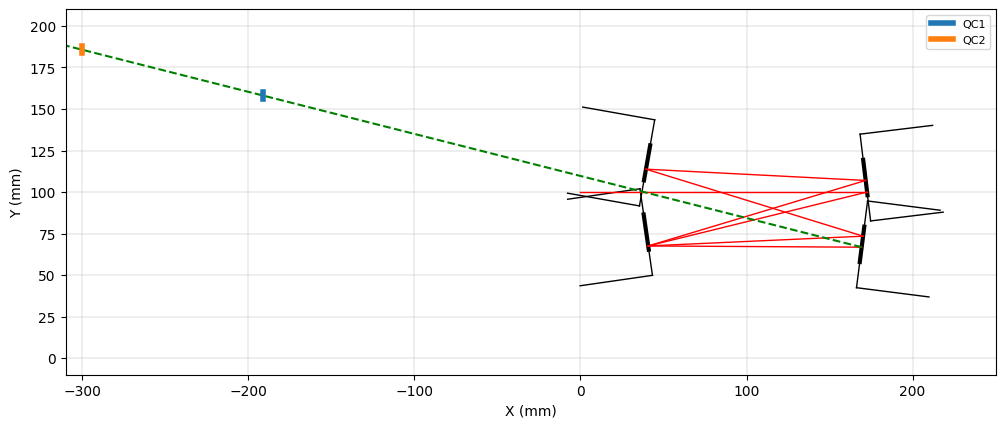

In [42]:
#Fitted Model
S.simulation(K1[0], K1[1],
             K2[0], K2[1],
             K3[0], K3[1],
             K4[0], K4[1],
             K1[2], K2[2], K3[2], K4[2])

In [43]:
S.simulation_identifier(K1[0], K1[1], 
             K2[0], K2[1], 
             K3[0], K3[1],
             K4[0], K4[1], 
             K1[2], K2[2], K3[2], K4[2]) #y191 is qc1, y595 is qc2

Exit slope: -0.253303830403
Total length: 1490.382101432735
y191 error: -0.178832594562
y300 error: -0.078715080616
y595 error: 0.195914888322


(-0.2533038304031788,
 1490.3821014327355,
 -0.17883259456220912,
 -0.07871508061572285,
 0.1959148883220223)

In [45]:
# Solves for path to mirror configuration that corresponds to a desired OPD
mirrors_opt, res, actuation_plan = S.choose_OPD(
    1495, K1, K2, K3, K4,
    M1_linear_loc=5,
    M2_linear_loc=0,
    M3_linear_loc=0,
    qc_plan_limit=1.,
    qc_detector_limit=3.9,
    qc_hardware_stop=3.5,
    final_qc_tolerance=0.5,
    u_min=0.1,
    u_max=0.9,
    max_axis_splits = 80,
    profile=True,
)

[choose_OPD 0.001s] start OPD=1490.382 target=1495.000 qc=(-0.179,0.196) u=[0.105,0.732] ok=True
[choose_OPD 0.002s] iteration=1 OPD=1490.382 target=1495.000 steps=0
[choose_OPD 0.025s] linear search stage=M1 valid_fraction=0.0724034 dt=0.023s
[choose_OPD 0.031s] target search stage=M1 reached_target=True move_fraction=0.0682867 dt=0.006s
[choose_OPD 0.032s] linear move stage=M1 reached_target=True hit_constraint=False steps_added=1 OPD=1495.000 qc=(-0.953,-0.579) u=[0.070,0.717] dt=0.001s
[choose_OPD 0.410s] final center solve SLSQP strict dt=0.377s success=True
[choose_OPD 0.411s] final center solve SLSQP strict accepted
[choose_OPD 0.411s] final center solve dt=0.378s changed=True success=True
[choose_OPD 10.764s] final center path fast path proposal dt=10.353s samples=5 steps=57 failure=None
[choose_OPD 11.437s] final center path fast path dense validation dt=0.673s samples=25 ok=True reason=None
[choose_OPD 11.437s] final center path dt=11.026s steps_added=57 failure=None
[choose_

In [46]:
mirrors_opt

(array([172.82965376, 108.7278626 ,  96.84261374]),
 array([39.5807544 , 75.89705939, 98.67644171]),
 array([169.54652483,  68.51238196,  82.77652933]),
 array([ 40.10752159, 117.5692052 ,  78.96755838]))

NOT CLIPPED, room to spare: 3.3296262780693553 mm
Laser Path: [(0, 100), (173.876972598716, 100.0), (40.84584754634764, 67.60684261862882), (170.48499500473628, 75.916744207088), (40.290476315389554, 118.50758866918741), (172.7537578261889, 109.36034360756578), (40.87206779583889, 67.43502005162097), (169.32965987516613, 66.80135613650194), (-800.2683002790152, 311.50484132796896)]
Total Laser Length: 1495.000384215977 mm
Total Number of Reflection (N_R) = 7


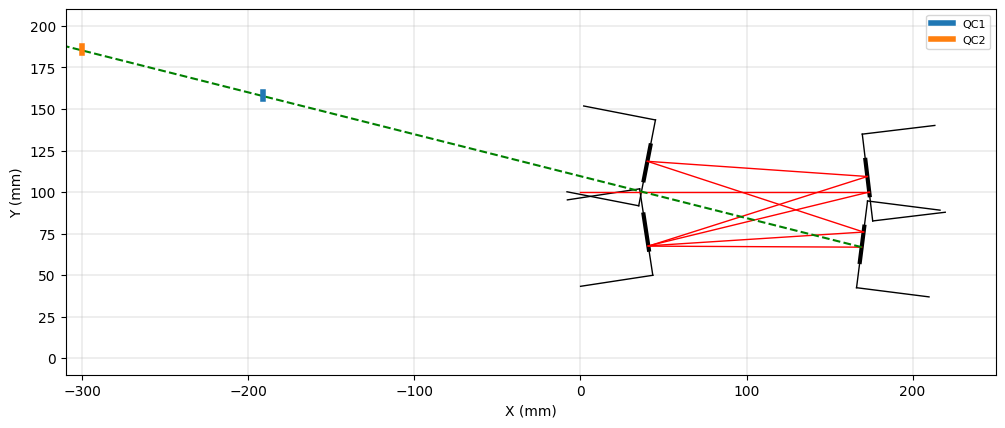

In [47]:
S.simulation(mirrors_opt[0][0], mirrors_opt[0][1], 
             mirrors_opt[1][0], mirrors_opt[1][1], 
             mirrors_opt[2][0], mirrors_opt[2][1],
             mirrors_opt[3][0], mirrors_opt[3][1], 
             mirrors_opt[0][2], mirrors_opt[1][2], mirrors_opt[2][2], mirrors_opt[3][2])

In [48]:
actuation_plan

{'steps': [{'step': 1,
   'fraction': 1.0,
   'mirrors': (array([172.82965376, 108.7278626 ,  96.9148784 ]),
    array([39.5807544 , 75.89705939, 98.21458556]),
    array([169.54652483,  68.51238196,  82.72558984]),
    array([ 40.10752159, 117.5692052 ,  79.95889787])),
   'commands': {'M1': {'dx': 1.2974482318285823, 'dangle': 0.0},
    'M2': {'dx': 0.0, 'dangle': 0.0},
    'M3': {'dx': 0.0, 'dangle': 0.0},
    'M4': {'dx': 0.0, 'dangle': 0.0}},
   'positions': {'M1': {'x': 172.82965375862892, 'angle': 96.91487839888649},
    'M2': {'x': 39.58075439947042, 'angle': 98.21458556023369},
    'M3': {'x': 169.5465248317428, 'angle': 82.72558984363927},
    'M4': {'x': 40.10752158632127, 'angle': 79.95889787075374}},
   'OPD': 1494.9999999999998,
   'qc1_error': -0.9533102975018437,
   'qc2_error': -0.5785628146176123,
   'qc_difference': -0.37474748288423143,
   'reflection_count': 7,
   'actuator': 'M1.dx',
   'axis_index': 0,
   'command_value': 1.2974482318285823,
   'single_actuator_s

In [49]:
mirrors, res, execution = A.execute_OPD_fixed_plan(
    1495, K1, K2, K3, K4,
    hardware=H,
    M1_linear_loc=5,
    M2_linear_loc=0,
    M3_linear_loc=0,
    dry_run=False,
    profile=True,
    qc_plan_limit=1,
    qc_detector_limit=3.9,
    qc_hardware_stop=3.5,
    final_qc_tolerance=0.5,
    qc_step_tolerance=0.20,
    max_rotation_chunk_substeps=20,
    max_rotation_chunks_per_step=100,
    rotation_settle_delay=0.5,
    linear_settle_delay=2.0,
    max_total_steps=150,
    choose_OPD_kwargs={
        "u_min": 0.1,
        "u_max": 0.9,
        "max_axis_splits": 80,
    },
)

[execute_fixed_OPD 11.550s] start target_OPD=1495.000 dry_run=False planned_steps=58 failure=None ignored_planner_failure=False
Moving KDC101 stage 27266900 to 1.2974482318285823 mm
Move complete for 27266900
[execute_fixed_OPD 15.529s] step=1/58 actuator=M1.dx miss=0.366 qc_x=(1.025,0.938)
[execute_fixed_OPD 21.047s] step=2/58 actuator=M2.dangle miss=0.156 qc_x=(0.033,-0.883)
[execute_fixed_OPD 26.069s] step=3/58 actuator=M4.dangle miss=0.198 qc_x=(0.877,0.495)
[execute_fixed_OPD 30.085s] step=4/58 actuator=M2.dangle miss=0.126 qc_x=(0.008,-0.901)
[execute_fixed_OPD 35.606s] step=5/58 actuator=M4.dangle miss=0.141 qc_x=(0.896,0.553)
[execute_fixed_OPD 40.126s] step=6/58 actuator=M2.dangle miss=0.105 qc_x=(-0.008,-0.914)
[execute_fixed_OPD 45.146s] step=7/58 actuator=M4.dangle miss=0.156 qc_x=(0.886,0.541)
[execute_fixed_OPD 49.664s] step=8/58 actuator=M2.dangle miss=0.114 qc_x=(0.000,-0.910)
[execute_fixed_OPD 54.685s] step=9/58 actuator=M4.dangle miss=0.156 qc_x=(0.886,0.540)
[execut

In [50]:
print("failure_reason:", execution["failure_reason"])
print("execution_log length:", len(execution["execution_log"]))

for s in execution["actuation_plan"]["steps"][:10]:
    print(
        s["step"],
        s.get("actuator"),
        s.get("axis_index"),
        s.get("command_value"),
        s.get("single_actuator_step"),
        "OPD=", s.get("OPD"),
        "qc=", (s.get("qc1_error"), s.get("qc2_error")),
    )

failure_reason: Fixed-plan final checks failed: final_OPD_within_tolerance
execution_log length: 58
1 M1.dx 0 1.2974482318285823 True OPD= 1494.9999999999998 qc= (-0.9533102975018437, -0.5785628146176123)
2 M2.dangle 3 0.018461106214800793 True OPD= 1495.6570163440826 qc= (0.07097587606986622, 0.9999999999027409)
3 M4.dangle 7 -0.03854548940725522 True OPD= 1494.9636183172504 qc= (-0.9999999991917434, -0.6496128487270312)
4 M2.dangle 3 0.019292354335533446 True OPD= 1495.6501536766991 qc= (0.07038692175962069, 0.99999999872324)
5 M4.dangle 7 -0.03852444946114986 True OPD= 1494.9568921243838 qc= (-0.9999999995479811, -0.6487085584905117)
6 M2.dangle 3 0.01928182348481755 True OPD= 1495.6430516034661 qc= (0.0697982953341807, 0.9999999991401296)
7 M4.dangle 7 -0.03850342712811994 True OPD= 1494.9499267123801 qc= (-0.9999999996857696, -0.6478048578612174)
8 M2.dangle 3 0.019271301430450194 True OPD= 1495.635710521763 qc= (0.06920999567859099, 0.9999999997322107)
9 M4.dangle 7 -0.0384824223

In [51]:
print("success:", execution["success"])
print("failure_reason:", execution["failure_reason"])
print("final_OPD:", execution["final_OPD"])
print("final_OPD_error:", execution["final_OPD_error"])
print("final_qc_y:", execution["final_qc_y"])
print("max_abs_measured_qc:", execution["max_abs_measured_qc"])
print("max_step_target_miss:", execution["max_step_target_miss"])
print("needs_final_recenter:", execution["needs_final_recenter"])

success: False
failure_reason: Fixed-plan final checks failed: final_OPD_within_tolerance
final_OPD: 1494.4802595301385
final_OPD_error: -0.5197404698615173
final_qc_y: [0.6239411446632127, 0.4045455588173373]
max_abs_measured_qc: 1.0245612676056337
max_step_target_miss: 0.36620007431673035
needs_final_recenter: True


In [179]:
execution

{'success': False,
 'failure_reason': 'Fixed-plan final checks failed: final_OPD_within_tolerance',
 'success_checks': {'no_failure_reason': True,
  'final_OPD_within_tolerance': False,
  'final_qc_required': False,
  'final_qc_within_tolerance': False,
  'needs_final_recenter': True,
  'final_OPD_error': 2.9215036936125216,
  'final_OPD_tolerance': 0.5,
  'final_qc_max_abs': 0.5058216718323384,
  'final_qc_tolerance': 0.5,
  'planner_failure_ignored': False,
  'planner_failure_reason': None},
 'fixed_plan': True,
 'planner_failure_ignored': False,
 'planner_failure_reason': None,
 'needs_final_recenter': True,
 'target_OPD': 1460.0,
 'final_OPD': 1462.9215036936125,
 'final_OPD_error': 2.9215036936125216,
 'final_sim_qc': [4.06433119729752, 6.876843929001495],
 'final_qc_x': [0.5058216718323384, -0.4903450118764845],
 'final_qc_y': [0.5058216718323384, -0.4903450118764845],
 'max_abs_measured_qc': 1.3554930876147009,
 'max_step_target_miss': 0.65949369657855,
 'max_abs_OPD_divergence'

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Reflection Positions During Fixed-Plan Execution'}, xlabel='Actuator step', ylabel='Reflection position u'>)

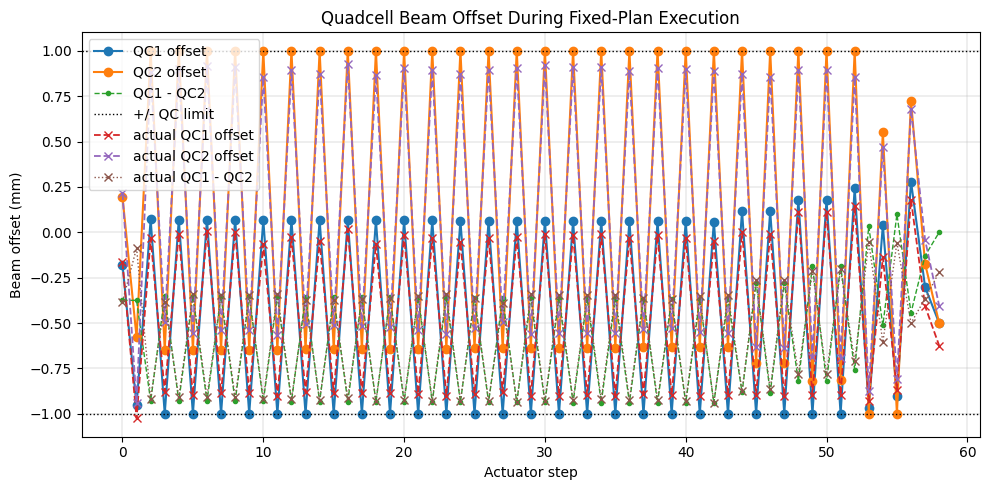

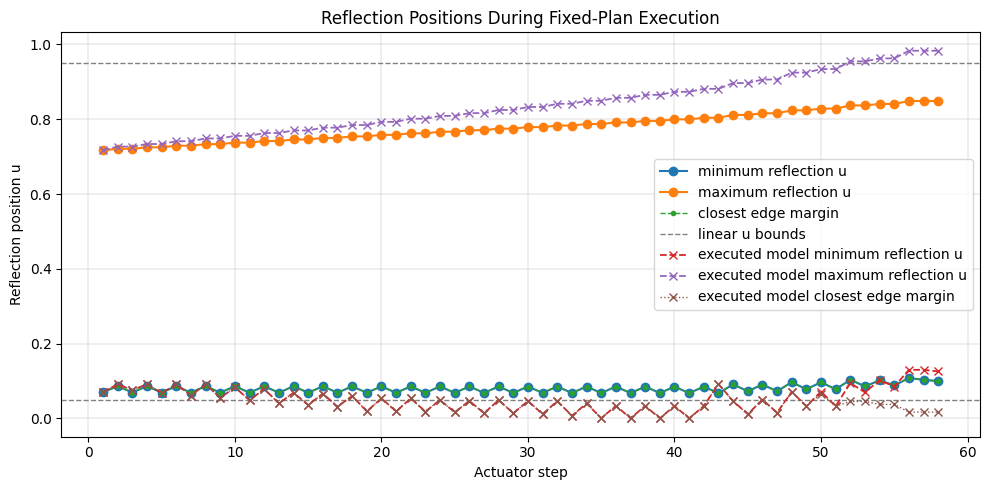

In [52]:
A.plot_fixed_plan_quadcell_overlay(execution)
A.plot_fixed_plan_reflection_u_overlay(execution)

NOT CLIPPED, room to spare: 0.7467048403764931 mm
Laser Path: [(0, 100), (164.92813881048804, 100.0), (40.67285984237148, 68.60405076189264), (170.03016568059985, 71.73349780460441), (39.028757010248256, 110.7555029486239), (164.14706896637216, 106.27960787869333), (40.444788020610844, 70.27268267131008), (169.63575051709375, 68.77781198304051), (-798.3426518685376, 319.81130081463226)]
Total Laser Length: 1462.921503693613 mm
Total Number of Reflection (N_R) = 7


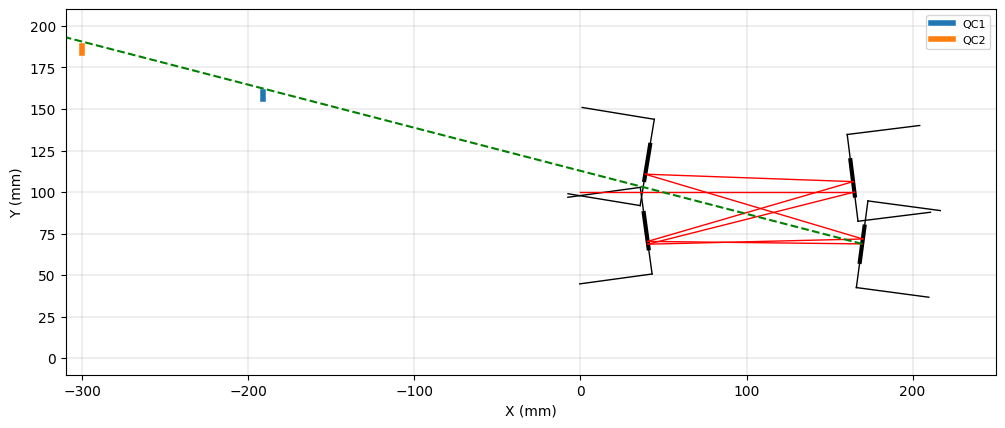

In [176]:
S.simulation(mirrors[0][0], mirrors[0][1], 
             mirrors[1][0], mirrors[1][1], 
             mirrors[2][0], mirrors[2][1],
             mirrors[3][0], mirrors[3][1], 
             mirrors[0][2], mirrors[1][2], mirrors[2][2], mirrors[3][2])

In [177]:
S.simulation_identifier(mirrors[0][0], mirrors[0][1], 
             mirrors[1][0], mirrors[1][1], 
             mirrors[2][0], mirrors[2][1],
             mirrors[3][0], mirrors[3][1], 
             mirrors[0][2], mirrors[1][2], mirrors[2][2], mirrors[3][2])

Exit slope: -0.259337902801
Total length: 1462.921503693613
y191 error: 4.064331197298
y300 error: 4.822162602634
y595 error: 6.876843929001


(-0.2593379028012475,
 1462.9215036936125,
 4.06433119729752,
 4.822162602633512,
 6.876843929001495)

In [67]:
import importlib
A = importlib.reload(A)

qc = H.quads.get_xy_position()
qc1_x, qc2_x = qc[0], qc[2]

print("raw qc:", qc)
print("hardware qc x:", qc1_x, qc2_x)
print("sim qc if sign=-1:", -qc1_x, -qc2_x)
print("sim qc if sign=+1:", qc1_x, qc2_x)

print("model qc:", S.quadcell_errors_from_mirrors(K1, K2, K3, K4))

raw qc: [2.6102726283723303, 0.45004700489178107, 3.572655801950523, 0.5261102722050427]
hardware qc x: 2.6102726283723303 3.572655801950523
sim qc if sign=-1: -2.6102726283723303 -3.572655801950523
sim qc if sign=+1: 2.6102726283723303 3.572655801950523


AttributeError: module 'Simulation' has no attribute 'quadcell_errors_from_mirrors'

In [161]:
execution

{'success': False,
 'failure_reason': 'Fixed-plan final checks failed: final_OPD_within_tolerance',
 'success_checks': {'no_failure_reason': True,
  'final_OPD_within_tolerance': False,
  'final_qc_required': False,
  'final_qc_within_tolerance': False,
  'needs_final_recenter': True,
  'final_OPD_error': -1440.0,
  'final_OPD_tolerance': 0.5,
  'final_qc_max_abs': 0.6571194146063747,
  'final_qc_tolerance': 0.5,
  'planner_failure_ignored': False,
  'planner_failure_reason': None},
 'fixed_plan': True,
 'planner_failure_ignored': False,
 'planner_failure_reason': None,
 'needs_final_recenter': True,
 'target_OPD': 1440.0,
 'final_OPD': 0.0,
 'final_OPD_error': -1440.0,
 'final_sim_qc': [-82.16654538631792, -196.59755324296992],
 'final_qc_x': [0.5261778613617427, -0.6571194146063747],
 'final_qc_y': [0.5261778613617427, -0.6571194146063747],
 'max_abs_measured_qc': 3.0834649078014036,
 'max_step_target_miss': 3.67432056645765,
 'max_abs_OPD_divergence': 0.0,
 'rollback_count': 0,
 'li

In [58]:
for s in execution["actuation_plan"]["steps"][:5]:
    print(
        s["step"],
        s["actuator"],
        "cmd=", s["command_value"],
        "OPD=", s["OPD"],
        "qc=", (s["qc1_error"], s["qc2_error"])
    )

1 M1.dx cmd= 1.4242972547661736 OPD= 1450.0 qc= (-0.4807247182268384, -1.4765858326259718)
2 M2.dangle cmd= 0.052903410129673034 OPD= 1451.8647833314953 qc= (2.4090829627650123, 2.9999999993549977)
3 M1.dangle cmd= 0.06403892536219757 OPD= 1449.2604794873323 qc= (-1.6705162092011108, -2.9999999988469312)
4 M2.dangle cmd= 0.07092062887913642 OPD= 1451.755975660241 qc= (2.2024562351542727, 2.999999999244494)
5 M1.dangle cmd= 0.06403117676710224 OPD= 1449.1499318682568 qc= (-1.8769105598170484, -2.999999999629381)


In [162]:
for e in execution["execution_log"]:
    print("\nstep", e["execution_step"], e["actuator"])
    print("command:", e["command_value"])
    print("planned_qc_y:", e["planned_qc_y"])
    print("before_qc_y:", e["before_qc_y"])
    print("after_qc_y:", e["after_qc_y"])
    print("miss:", e["qc_target_miss"])
    print("detail:", e["detail"])


step 1 M1.dx
command: 1.796800104092
planned_qc_y: [1.7399927463738436, 0.12070297178945566]
before_qc_y: [0.7115077407648872, -0.921722284996067]
after_qc_y: [3.0834649078014036, 2.9659134597034025]
miss: 3.1464488187584365
detail: {'kind': 'linear', 'serial': '27266900', 'planned_sim_delta': 1.796800104092, 'hardware_delta': 1.796800104092, 'actual_sim_delta': 1.79679, 'before_position': 0.95147, 'after_position': 2.74826}

step 2 M2.dangle
command: 0.036873697620350754
planned_qc_y: [-0.2716081998662503, -2.999999998075282]
before_qc_y: [3.0834649078014036, 2.9659134597034025]
after_qc_y: [-0.14952457979651163, -3.0052760487640446]
miss: 0.1221975736264951
detail: {'kind': 'rotation_fixed_plan', 'controller': 'newport', 'actuator': 3, 'planned_angle_delta': 0.036873697620350754, 'degrees_per_substep': 0.0023, 'target_qc_x': [-0.2716081998662503, -2.999999998075282], 'target_qc_y': [-0.2716081998662503, -2.999999998075282], 'start_qc_x': [3.0834649078014036, 2.9659134597034025], 'st

In [37]:
e = execution["execution_log"][0]
print(e["detail"])

{'kind': 'linear', 'serial': '27266900', 'planned_sim_delta': 4.041582190743128, 'hardware_delta': 4.041582190743128, 'actual_sim_delta': 4.04, 'before_position': 0.0, 'after_position': 4.04}


In [111]:
def linear_pos(serial):
    p = H.stages.get_position(serial)
    print(f"{serial} position = {p}")
    return p

def linear_move_relative(serial, delta, settle=2.0):
    p0 = H.stages.get_position(serial)
    print(f"before: {p0}")

    print(f"moving relative by {delta}")
    H.stages.move_relative(serial, delta)

    time.sleep(settle)

    p1 = H.stages.get_position(serial)
    print(f"after: {p1}")
    print(f"software delta: {p1 - p0}")

    return p0, p1

In [20]:
linear_pos("27266900")

27266900 position = 2.78553


2.78553

In [119]:
linear_move_relative("27266900", -1, settle=2.0)

before: 0.0
moving relative by -1
Moving KDC101 stage 27266900 to -1.0 mm


MoveToInvalidPositionException: Cannot move to requested position
   at Thorlabs.MotionControl.GenericMotorCLI.AdvancedMotor.GenericAdvancedMotorCLI.VerifyDeviceMovement(Int32 functionDepth, Decimal position, PositionType positionType)
   at Thorlabs.MotionControl.GenericMotorCLI.AdvancedMotor.GenericAdvancedMotorCLI.MoveTo(Decimal position, Int32 waitTimeout)

In [33]:
H.shutdown()

Shutting down piezos...
Shutting down quadcells...
Shutdown aligner with serial 69253622
Shutdown aligner with serial 69253977
Shutting down KDC101 linear stages...
Shutdown KDC101 linear stage with serial 27266900
Shutdown KDC101 linear stage with serial 27266901
Shutdown KDC101 linear stage with serial 27601694
Shutting down rotation stages...
Shutdown Newport rotation controller newport
All hardware safely shut down.


In [ ]:
linear_pos("27266900")
linear_move_relative("27266900", 0.001, settle=2.0)
linear_move_relative("27266900", -0.001, settle=2.0)

In [75]:
import cv2 as cv

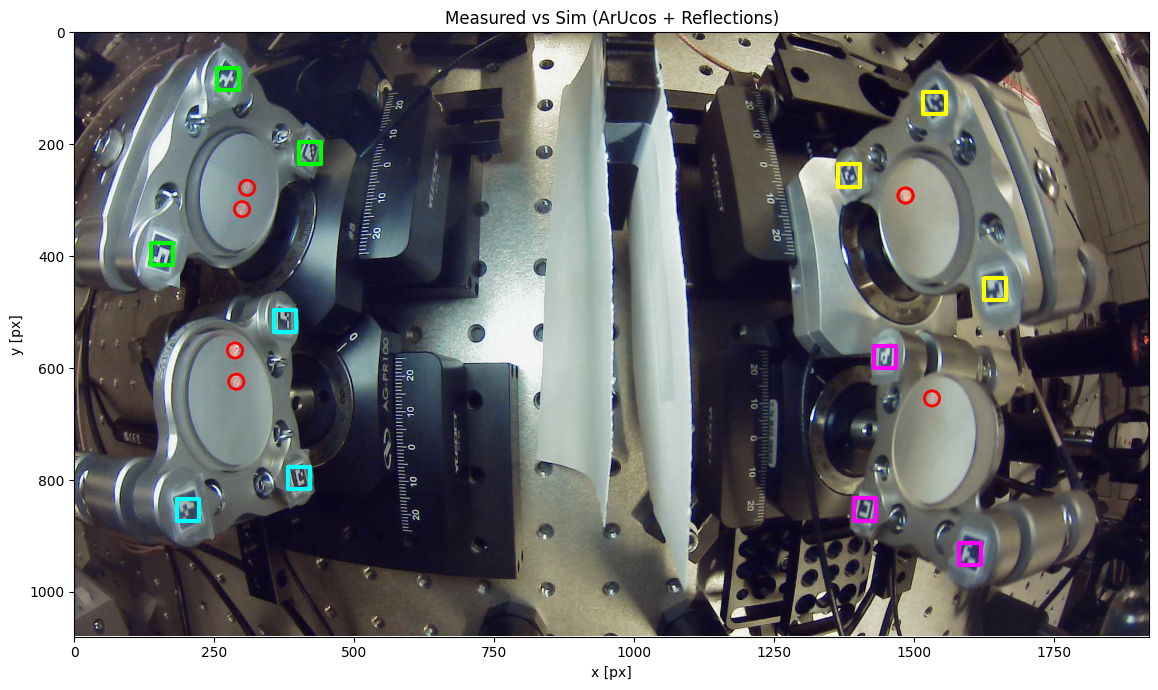

(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'center': 'Measured vs Sim (ArUcos + Reflections)'}, xlabel='x [px]', ylabel='y [px]'>)

In [80]:
# ---- Load images ----
img_light = cv.imread("images/6-08-L4.jpg")
img_dark  = cv.imread("images/6-08-D4.jpg")
gray = cv.cvtColor(img_dark, cv.COLOR_BGR2GRAY)

# ---- Measured points ----
aruco_centers_12 = S.camera_arucos("images/6-08-L4.jpg")                 # list of 12
aruco_meas = S.group_aruco_centers_by_mirror(aruco_centers_12)

refl_meas = S.reflec_pts_cam(gray, show=False)                     # dict M1..M4

# ---- Sim points (from solved theta) ----
M1x, M2x, M3x, M4x, M1y, M2y, M3y, M4y, M1a, M2a, M3a, M4a = x[0], x[1], x[2], x[3], x[4], x[5], x[6], x[7], x[8], x[9], x[10], x[11]

aruco_sim = S.sim_aruco_pts_by_mirror(M1x, M2x, M3x, M4x, M1y, M2y, M3y, M4y, M1a, M2a, M3a, M4a)
refl_sim  = S.sim_reflection_pts_by_mirror(M1x, M2x, M3x, M4x, M1y, M2y, M3y, M4y, M1a, M2a, M3a, M4a)

# ---- Overlay plot ----
S.overlay_reflections_and_aruco(
    img_bgr=img_light,
    reflec_meas_by_mirror=refl_meas,
    aruco_meas_by_mirror=aruco_meas,
    reflec_sim_by_mirror=None,
    aruco_sim_by_mirror=None,
    title="Measured vs Sim (ArUcos + Reflections)"
)

In [81]:
res = S.optimize_inverse(M1, M2, M3, M4, img_path_light='images/6-08-L1.jpg', img_path_dark='images/6-08-D1.jpg',
                   qc1_disp=None, qc2_disp=None)

Exit slope: -0.246423177391
Total length: 1494.023637560200
y191 error: -4.660800748686
y300 error: -5.310674413100
y595 error: -7.065837082846
Exit slope: -0.246423177391
Total length: 1494.023645702626
y191 error: -4.660801945125
y300 error: -5.310675609539
y595 error: -7.065838279285
Exit slope: -0.246423177391
Total length: 1494.023636480785
y191 error: -4.660800591722
y300 error: -5.310674256137
y595 error: -7.065836925883
Exit slope: -0.246423177391
Total length: 1494.023648151672
y191 error: -4.660799506388
y300 error: -5.310673170803
y595 error: -7.065835840549
Exit slope: -0.246423177391
Total length: 1494.023636524248
y191 error: -4.660800869048
y300 error: -5.310674533463
y595 error: -7.065837203209
Exit slope: -0.246423177391
Total length: 1494.023638191577
y191 error: -4.660800841459
y300 error: -5.310674505874
y595 error: -7.065837175620
Exit slope: -0.246423177391
Total length: 1494.023637132089
y191 error: -4.660800686432
y300 error: -5.310674350846
y595 error: -7.06583

In [82]:
x = res.x

K1 = np.array([x[0], x[4], x[8]])
K2 = np.array([x[1], x[5], x[9]])
K3 = np.array([x[2], x[6], x[10]])
K4 = np.array([x[3], x[7], x[11]])

In [84]:
K1, K2, K3, K4

(array([161.63958555, 108.76839189,  96.45142482]),
 array([39.47417847, 76.24278375, 96.37998894]),
 array([169.23511135,  68.79466864,  81.77841569]),
 array([ 40.15127225, 117.76531573,  80.78461946]))